# 00 - Data Audit

Load the panel, verify structure, and describe each city before any analysis.

In [1]:
# Data setup
# Set DATA_FILE to 'city_month_panel.parquet' after running build_real_panel.py
DATA_FILE = "city_month_panel.parquet"       # synthetic data (real not downloaded)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel = pd.read_parquet(DATA_DIR / DATA_FILE)
panel["month"] = pd.to_datetime(panel["month"])

regs = pd.read_csv("../data/regulations.csv", parse_dates=["enforcement_date"])

print(f"Panel: {panel.shape}  |  Cities: {sorted(panel['city'].unique())}")
print(f"Date range: {panel['month'].min().date()} to {panel['month'].max().date()}")

Panel: (288, 15)  |  Cities: ['Amsterdam', 'Barcelona', 'Florence', 'Lisbon', 'New York City', 'Vienna']
Date range: 2021-01-01 to 2024-12-01


## Panel dimensions

In [2]:
print(f"Rows      : {len(panel):,}")
print(f"Cities    : {panel['city'].nunique()}")
print(f"Months    : {panel['month'].nunique()}")
print(f"Is real?  : {not panel['is_simulated'].all()}")
print()
print(panel.groupby("city")[["log_listings","mean_price_usd","availability_rate","entire_home_share"]].mean().round(3))

Rows      : 288
Cities    : 6
Months    : 48
Is real?  : False

               log_listings  mean_price_usd  availability_rate  \
city                                                             
Amsterdam             9.418         166.022              0.432   
Barcelona             9.745         138.294              0.512   
Florence              9.017         148.007              0.460   
Lisbon                9.870         125.752              0.549   
New York City         9.450         189.111              0.482   
Vienna                9.017         109.833              0.503   

               entire_home_share  
city                              
Amsterdam                  0.608  
Barcelona                  0.740  
Florence                   0.636  
Lisbon                     0.694  
New York City              0.623  
Vienna                     0.578  


## Treatment structure

In [3]:
treated = panel[panel["is_treated_city"]].groupby("city").agg(
    first_month=("month","min"),
    treat_start=("post", lambda x: panel.loc[x.index[x].min(), "month"] if x.any() else None),
    n_pre=("post", lambda x: (~x).sum()),
    n_post=("post", "sum"),
)
print(treated)

              first_month treat_start  n_pre  n_post
city                                                
Florence       2021-01-01  2023-10-01     33      15
New York City  2021-01-01  2023-09-01     32      16


## Time series overview — all cities

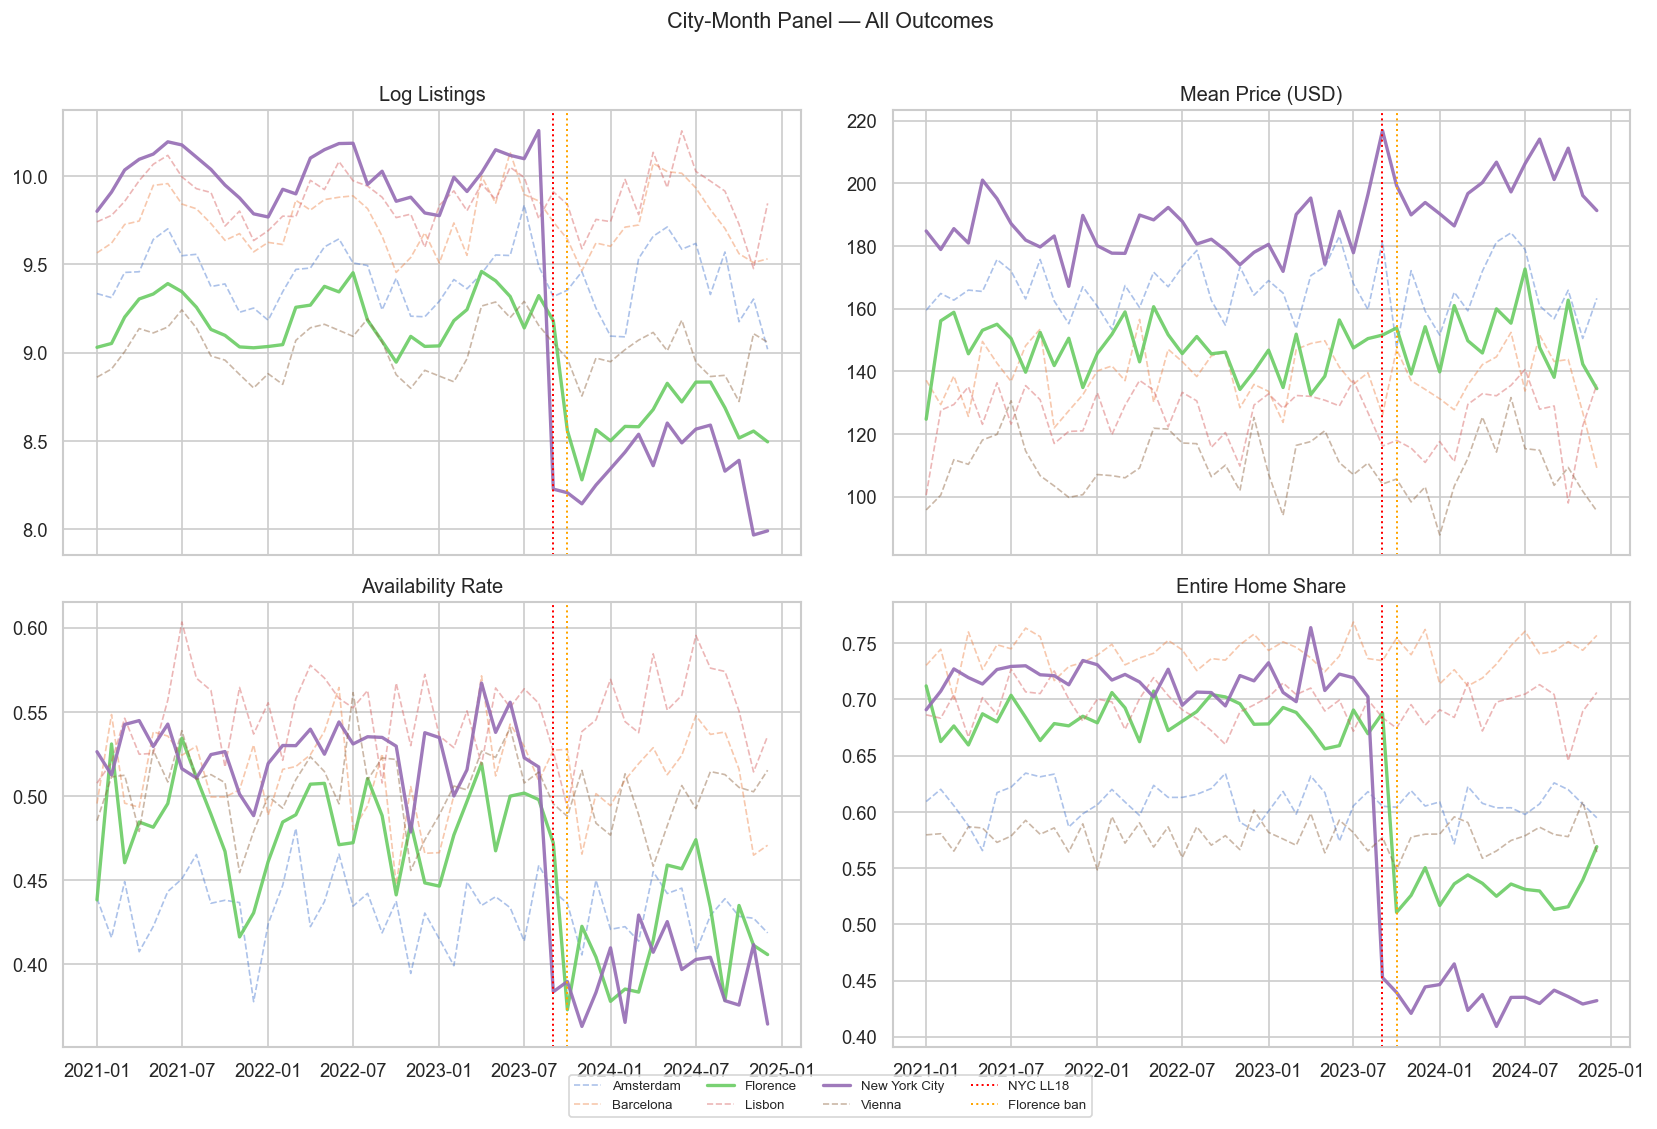

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
outcomes = ["log_listings", "mean_price_usd", "availability_rate", "entire_home_share"]
titles   = ["Log Listings", "Mean Price (USD)", "Availability Rate", "Entire Home Share"]

for ax, col, title in zip(axes.flat, outcomes, titles):
    for city, grp in panel.groupby("city"):
        style = dict(lw=2.0, alpha=0.9) if city in ("New York City","Florence") else dict(lw=1.0, alpha=0.45, ls="--")
        ax.plot(grp["month"], grp[col], label=city, **style)
    ax.axvline(pd.Timestamp("2023-09-01"), color="red",    ls=":", lw=1.2, label="NYC LL18")
    ax.axvline(pd.Timestamp("2023-10-01"), color="orange", ls=":", lw=1.2, label="Florence ban")
    ax.set_title(title)
    ax.set_xlabel("")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("City-Month Panel — All Outcomes", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "00_all_cities_overview.png", bbox_inches="tight")
plt.show()